In [ ]:
import pryngles as pr

import spiceypy as spy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.visualization import astropy_mpl_style
plt.style.use(astropy_mpl_style)

%matplotlib inline

In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## **Building System**

In [ ]:
# WASP 43b Parameters
wasp_params = dict()

wasp_params['per'] = 0.81347753       # Period [days]
wasp_params['a_abs'] = 0.01526        # The absolute value of the semi-major axis [AU]
wasp_params['inc'] = 90               # Inclination [degrees]
wasp_params['ecc'] = 0.0              # Eccentricity
wasp_params['w'] = 90*0                 # Argument of periastron
wasp_params['rp'] = 0.1594            # Planet to star radius ratio
wasp_params['a'] = 4.855              # Semi-major axis scaled by stellar radius

# Temperature Model
wasp_params['xi'] = 0.3       # Ratio of radiative to advective timescale (Zhang_2017_ApJ_836_73)
wasp_params['T_n'] = 1128     # Temperature of nightside
wasp_params['delta_T'] = 942    # Day-night temperature contrast
wasp_params['T_s'] = 4500    # Temperature of the star
            
# Bandwidth
wasp_params['l1'] = 1.1e-6       # The starting wavelength in meters
wasp_params['l2'] = 1.7e-6       # The ending wavelength in meters

In [4]:
# Setting Star Values
R_star_AU   = wasp_params['a_abs'] / wasp_params['a']
R_sun_AU    = pr.Consts.rsun/pr.Const.au
R_star_Rsun = R_star_AU / R_sun_AU

R_star = R_star_Rsun * pr.Consts.rsun # [m]

M_star = 4*np.pi**2*(wasp_params['a_abs']*pr.Consts.au)**3/(pr.consts.GSI*(wasp_params['per']*pr.Consts.day)**2) # [kg]

### **Pryngles System**

In [6]:
system = pr.System()

star = system.add(m = M_star/system.um, T_eff = wasp_params['T_s'], 
                  radius = R_star/system.ul, nspangles = 100)

planet = system.add(kind = 'Planet', parent = star, 
                    radius = wasp_params['rp']*star.radius,
                    a = wasp_params['a_abs'], e = 0, m = 0,
                    inc = (90 - wasp_params['inc'])*pr.DEG, 
                    omega = wasp_params['w']*pr.DEG)

# ring = system.add(kind = "Ring", parent = planet,
#                   i = 90*pr.DEG, roll = -66*pr.DEG)

In [7]:
# Set Observer to Primary Transit
system.n_obs = spy.eul2m(planet.omega, planet.inc, 0, 3,1,3)[0]

# Build Rebound Simulation
system.initialize_simulation()

# Spangle the system
system.spangle_system()

# Tidally Locked
# system.data.loc[system.data.name == 'Planet', 'w'] = 2*np.pi/system.sim.orbit.Ps[0]

### **Visualizing System**

(np.int64(0), np.int64(0))

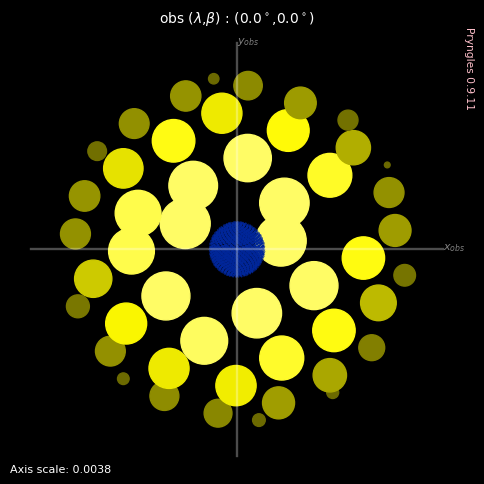

In [8]:
system.sg.plot2d()

## **Set Temperature Models**

In [22]:
T_uniform_model = {
    "type": "Uniform Temperature",
    "params": dict(T_planet = wasp_params['T_n'])}

T_two_temp_model = {
    "type": "Two Temperature",
    "params": dict(T_day = wasp_params['T_n'] + wasp_params['delta_T'],
                   T_night = wasp_params['T_n'])}

T_zhang_showman_model = {
    "type": "Zhang-Showman",
    "params": dict(T_night = wasp_params['T_n'],
                   Delta_T = wasp_params['delta_T'],
                   xi_ratio = wasp_params['xi'])}

## **Computing Lightcurve**

In [23]:
cond_planet = (system.data.name == planet.name)

# Times for integration
ts = np.linspace(0, system.sim.orbit.Ps[0], 100)*system.ut/pr.Consts.day # [days]

flux_uniform = np.zeros_like(ts)
flux_two_temp = np.zeros_like(ts)
flux_zhang = np.zeros_like(ts)

for i, t in enumerate(ts*pr.Consts.day/system.ut):

    # Integrate the system
    system.integrate_perspective(t)

    #--------------------------------------------------------------------------

    # Uniform Temperature
    planet.set_temperature_model(T_uniform_model)

    system.update_ThermalEmission(lambda_min = wasp_params['l1'], 
                                  lambda_max = wasp_params['l2'])
    
    flux_uniform[i] = system.data.loc[cond_planet, 'thermal_flux'].sum()*1e6

    #--------------------------------------------------------------------------

    # Two Temperature
    planet.set_temperature_model(T_two_temp_model)

    system.update_ThermalEmission(lambda_min = wasp_params['l1'], 
                                  lambda_max = wasp_params['l2'])
    
    flux_two_temp[i] = system.data.loc[cond_planet, 'thermal_flux'].sum()*1e6

    #--------------------------------------------------------------------------

    # Zhang Temperature
    planet.set_temperature_model(T_zhang_showman_model)
    
    system.update_ThermalEmission(lambda_min = wasp_params['l1'], 
                                  lambda_max = wasp_params['l2'])
    
    flux_zhang[i] = system.data.loc[cond_planet, 'thermal_flux'].sum()*1e6

## **Plotting Lightcurve**

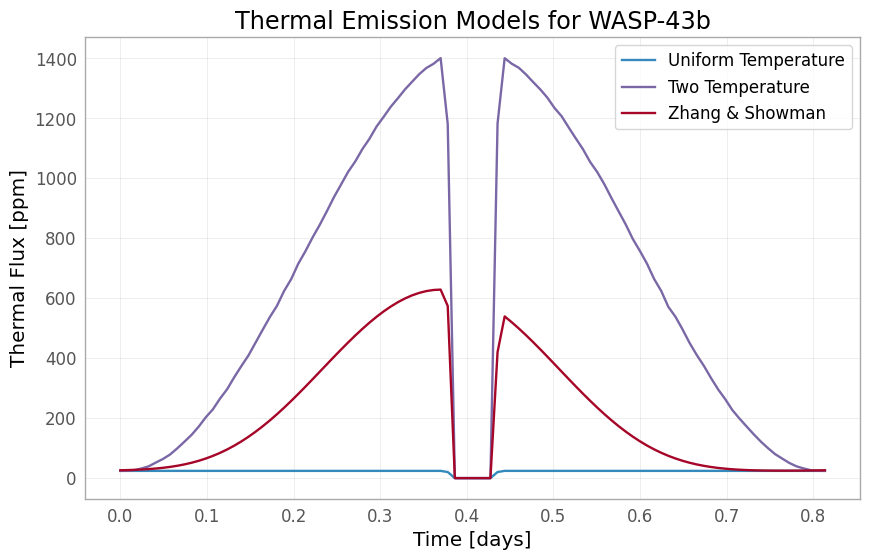

In [24]:
plt.figure(figsize=(10,6))

plt.plot(ts, flux_uniform, label = 'Uniform Temperature', color = 'C0')
plt.plot(ts, flux_two_temp, label = 'Two Temperature', color = 'C1')
plt.plot(ts, flux_zhang, label = 'Zhang & Showman', color = 'C2')

plt.xlabel('Time [days]')
plt.ylabel('Thermal Flux [ppm]')
plt.title('Thermal Emission Models for WASP-43b')

plt.legend()
plt.grid(linewidth=0.5, alpha=0.3)

plt.show()